# Sparse identification of FitzHugh–Nagumo dynamics

This **deep-dive tutorial** walks through sparse drift inference for a FitzHugh–Nagumo (FHN) SDE. We use a **polynomial library** (monomials in $v$ and $w$) with a **Laplace prior** on the coefficients—a simple SINDy-style approach that encourages sparsity and recovers the true equation structure. We fit the model via **SVI with AutoDelta** (MAP estimation) with both states observed, then compare the recovered equations and filtered trajectories against the ground truth.

## FitzHugh–Nagumo dynamics

The FHN system has state $x = (v, w)$ evolving according to an SDE with drift
$$\dot{v} = v - \frac{1}{3}v^3 - w + I, \qquad \dot{w} = a(v + b - c\,w)$$
plus **Brownian motion** (diffusion) in the state. We take $a=0.08$, $b=0.7$, $c=0.8$, $I=0.5$. The data is thus noisy from both the stochastic dynamics and the observation process. We will express the drift as $f(x) = \Theta\,\phi(x)$ where $\phi(x)$ is a polynomial basis (monomials in $v$, $w$) and $\Theta$ is a coefficient matrix. A **Laplace prior** on $\Theta$ shrinks unused terms toward zero, recovering the sparse structure. Observations are the state plus Gaussian noise.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDelta

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    SDESimulator,
)

import matplotlib.pyplot as plt


## True system

Define the true FitzHugh–Nagumo drift. We will later build the full DynamicalModel by piping in this drift and spreading shared arguments from a dict.

In [2]:
# FitzHugh–Nagumo parameters
_a, _b, _c, _I = 0.08, 0.7, 0.8, 0.5

def fitzhugh_nagumo_drift(x):
    v, w = x[0], x[1]
    dv = v - (1/3) * v**3 - w + _I
    dw = _a * (v + _b - _c * w)
    return jnp.array([dv, dw])

state_dim = 2

## Model configuration

Shared settings for the SDE simulator, observation schedule, and SVI inference.

In [3]:
initial_cov_scale = 1.0
emission_cov_scale = 0.01
diffusion_coeff = 0.01
obs_times = jnp.arange(0.0, 50.0, 0.1)

observation_dim = 2  # observation_dim=1 also works (observe only v)
# Setup: RNG keys
key = jr.PRNGKey(0)
key, k_data, k_svi, k_nuts, k_filter = jr.split(key, 5)

## Shared DynamicalModel kwargs 

Collect commonly used kwargs for DynamicalModel into a single dictionary for convenience. This includes state and observation dimensions, initial condition distribution, and the observation model. These shared arguments will be supplied to each DynamicalModel instantiation, ensuring consistency across experiments. Example: see `dynamics_kwargs` in the next code cell.



In [4]:
H_obs = jnp.eye(observation_dim, state_dim)
R_obs = emission_cov_scale * jnp.eye(observation_dim)

# DynamicalModel arguments that don't change across models
dynamics_kwargs = dict(
    initial_condition=dist.MultivariateNormal(
        loc=jnp.zeros(state_dim),
        covariance_matrix=initial_cov_scale * jnp.eye(state_dim),
    ),
    observation_model=LinearGaussianObservation(H=H_obs, R=R_obs),
)

# adjust_rhs is a helper function to ensure the state remains within the bounds [-100, 100] and the derivative remains within the bounds [-1000, 1000].
from cd_dynamax import adjust_rhs
def make_state_evolution(drift_fn):
    _drift_fn = lambda x, u, t: adjust_rhs(x, drift_fn(x, u, t))
    return ContinuousTimeStateEvolution(
        drift=drift_fn,
        diffusion_coefficient=lambda x, u, t: diffusion_coeff * jnp.eye(state_dim),
    )


## Data generation

We simulate from the **true** FHN drift using an SDE simulator. The model observes the state at `obs_times` with Gaussian noise.

In [5]:
# True system: pipe in drift, **kwargs the rest
def model_with_true_drift(obs_times=None, obs_values=None):
    return dsx.sample("f", DynamicalModel(
        state_evolution=make_state_evolution(lambda x, u, t: fitzhugh_nagumo_drift(x)),
        **dynamics_kwargs
    ), obs_times=obs_times, obs_values=obs_values)

predictive = Predictive(model_with_true_drift, num_samples=1, exclude_deterministic=False)
with SDESimulator():
    synthetic = predictive(k_data, obs_times=obs_times)
obs_values = synthetic["observations"][0]
states = synthetic["states"][0]
times_1d = jnp.asarray(obs_times).squeeze()

/Users/levinema/Projects/research/dynestyx/dynestyx/dynamical_models.py:77: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


### Data visualization

Time series of the latent state and noisy observations, and the phase-space trajectory.

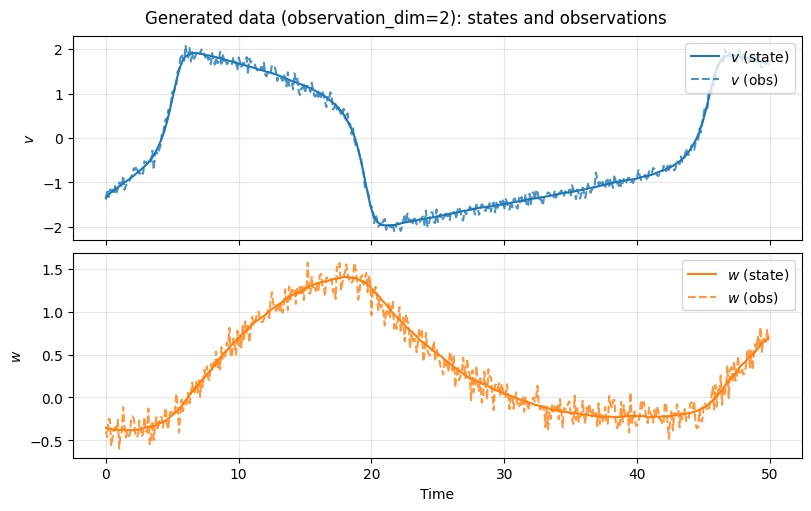

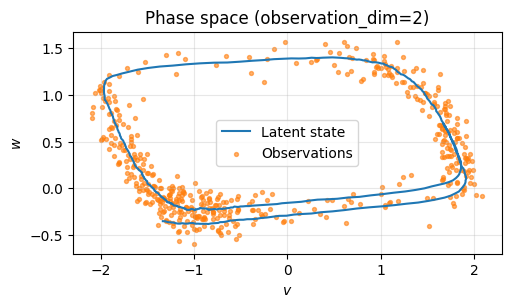

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, constrained_layout=True)
axes[0].plot(times_1d, states[:, 0], label="$v$ (state)", color="C0")
axes[0].plot(times_1d, obs_values[:, 0], linestyle="--", alpha=0.8, label="$v$ (obs)", color="C0")
axes[0].set_ylabel("$v$")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[1].plot(times_1d, states[:, 1], label="$w$ (state)", color="C1")
if observation_dim >= 2:
    axes[1].plot(times_1d, obs_values[:, 1], linestyle="--", alpha=0.8, label="$w$ (obs)", color="C1")
axes[1].set_ylabel("$w$")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
fig.suptitle(f"Generated data (observation_dim={observation_dim}): states and observations")
plt.show()

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
ax.plot(states[:, 0], states[:, 1], color="C0", label="Latent state", linewidth=1.5)
if observation_dim == 1:
    ax.scatter(obs_values[:, 0], jnp.zeros_like(obs_values[:, 0]), s=8, alpha=0.6, color="C1", label="Observations (v)")
else:
    ax.scatter(obs_values[:, 0], obs_values[:, 1], s=8, alpha=0.6, color="C1", label="Observations")
ax.set_xlabel("$v$")
ax.set_ylabel("$w$")
ax.set_title(f"Phase space (observation_dim={observation_dim})")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()

## Polynomial library and true coefficients

Library terms (monomials in $v$, $w$): $1$, $v$, $w$, $v^2$, $vw$, $w^2$, $v^3$, $v^2w$, $vw^2$, $w^3$. The true FHN drift uses only a subset. We build the coefficient matrix $\Theta \in \mathbb{R}^{2 \times 10}$ so that $f(x) = \Theta\,\phi(x)$.

In [7]:
TERM_NAMES = ["1", "v", "w", "v²", "vw", "w²", "v³", "v²w", "vw²", "w³"]
N_TERMS = len(TERM_NAMES)


def monomials(x):
    """Evaluate polynomial basis at state x = (v, w). Returns (N_TERMS,)."""
    v, w = x[0], x[1]
    return jnp.array([
        1.0, v, w, v**2, v * w, w**2, v**3, v**2 * w, v * w**2, w**3,
    ])


# True coefficient matrix (state_dim x N_TERMS) for FHN: dv = v - v³/3 - w + I, dw = _a*(v + _b - _c*w)
true_Theta = jnp.zeros((state_dim, N_TERMS))
true_Theta = true_Theta.at[0, 0].set(_I)       # 1
true_Theta = true_Theta.at[0, 1].set(1.0)     # v
true_Theta = true_Theta.at[0, 2].set(-1.0)    # w
true_Theta = true_Theta.at[0, 6].set(-1.0 / 3)  # v³
true_Theta = true_Theta.at[1, 0].set(_a * _b)  # 1
true_Theta = true_Theta.at[1, 1].set(_a)       # v
true_Theta = true_Theta.at[1, 2].set(-_a * _c)  # w

print("True coefficient matrix (rows: dv, dw; cols: library terms):")
print(jnp.round(true_Theta, 4))

True coefficient matrix (rows: dv, dw; cols: library terms):
[[ 0.5     1.     -1.      0.      0.      0.     -0.3333  0.      0.
   0.    ]
 [ 0.056   0.08   -0.064   0.      0.      0.      0.      0.      0.
   0.    ]]


## Model discovery

Build a Dynestyx SDE model with a sparsifying (Laplace) prior over polynomial drift coefficients.

In [8]:
def model_with_polynomial_drift(obs_times=None, obs_values=None):
    Theta = numpyro.sample(
        "Theta",
        dist.Laplace(0.0, 0.15).expand([state_dim, N_TERMS]).to_event(2),
    )

    def drift(x, u, t):
        phi = monomials(x)
        return Theta @ phi

    return dsx.sample("f", DynamicalModel(
        state_evolution=make_state_evolution(drift),
        **dynamics_kwargs
    ), obs_times=obs_times, obs_values=obs_values)



Build the conditioned model via filtering + data conditioning

In [9]:
def data_conditioned_model(obs_times=None, obs_values=None):
    with Filter():
        return model_with_polynomial_drift(obs_times=obs_times, obs_values=obs_values)

Run SVI for MAP estimation...

In [10]:
# Note that we get "close" to a good model within 1000 steps, but the last 3000 steps are needed to get a high-fidelity final MAP estimate here.
num_steps = 4000
optimizer = numpyro.optim.Adam(step_size=1e-2)
guide = AutoDelta(data_conditioned_model)
svi = SVI(data_conditioned_model, guide, optimizer, loss=Trace_ELBO())
svi_result = svi.run(k_svi, num_steps=num_steps, obs_times=obs_times, obs_values=obs_values)
Theta_inferred = guide.median(svi_result.params)["Theta"]

100%|██████████| 4000/4000 [24:19<00:00,  2.74it/s, init loss: 15848.3115, avg. loss [3801-4000]: -852.5349]


### SVI loss curve

The negative ELBO decreases as the MAP estimate is refined.

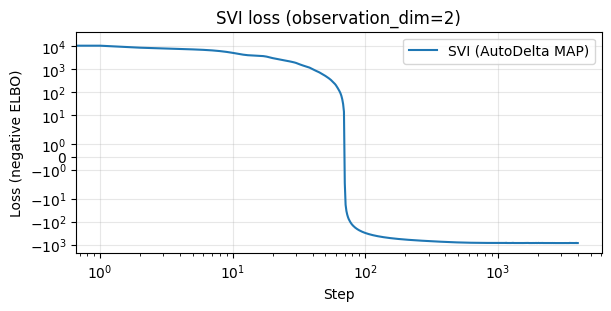

In [11]:
fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)
ax.plot(svi_result.losses, color="C0", label="SVI (AutoDelta MAP)")
ax.set_yscale("symlog")
ax.set_xscale("log")
ax.set_xlabel("Step")
ax.set_ylabel("Loss (negative ELBO)")
ax.set_title(f"SVI loss (observation_dim={observation_dim})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Parameter recovery

Compare true vs inferred polynomial coefficients. Each cell is color-coded by value (red = positive, blue = negative). The Laplace prior shrinks unused terms toward zero, recovering the sparse structure.

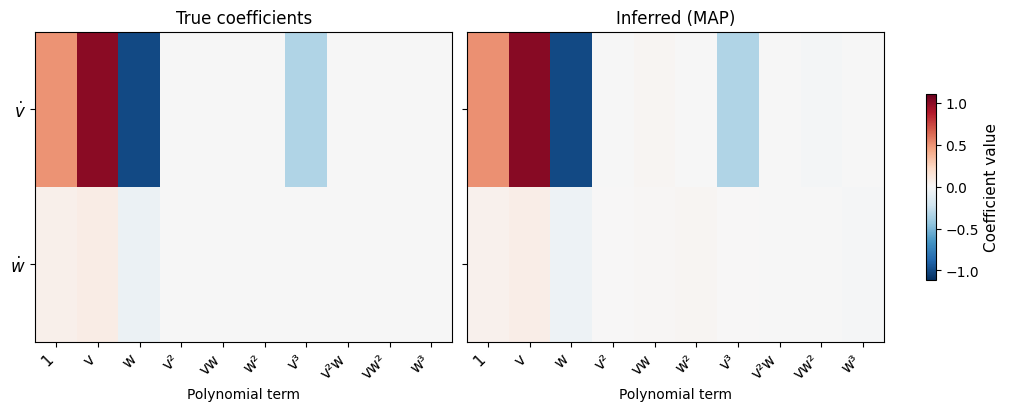

In [12]:
vmax = max(float(jnp.abs(true_Theta).max()), float(jnp.abs(Theta_inferred).max())) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True, constrained_layout=True)

im0 = axes[0].imshow(
    jnp.asarray(true_Theta),
    cmap="RdBu_r",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].set_xticks(range(N_TERMS))
axes[0].set_xticklabels(TERM_NAMES, rotation=45, ha="right", fontsize=11)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels([r"$\dot{v}$", r"$\dot{w}$"], fontsize=12)
axes[0].set_title("True coefficients")
axes[0].set_xlabel("Polynomial term")

im1 = axes[1].imshow(
    jnp.asarray(Theta_inferred),
    cmap="RdBu_r",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].set_xticks(range(N_TERMS))
axes[1].set_xticklabels(TERM_NAMES, rotation=45, ha="right", fontsize=11)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels([r"$\dot{v}$", r"$\dot{w}$"], fontsize=12)
axes[1].set_title("Inferred (MAP)")
axes[1].set_xlabel("Polynomial term")

cbar = fig.colorbar(im1, ax=axes, shrink=0.6, aspect=20)
cbar.set_label("Coefficient value", fontsize=11)
plt.show()

/Users/levinema/Projects/research/dynestyx/dynestyx/dynamical_models.py:77: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


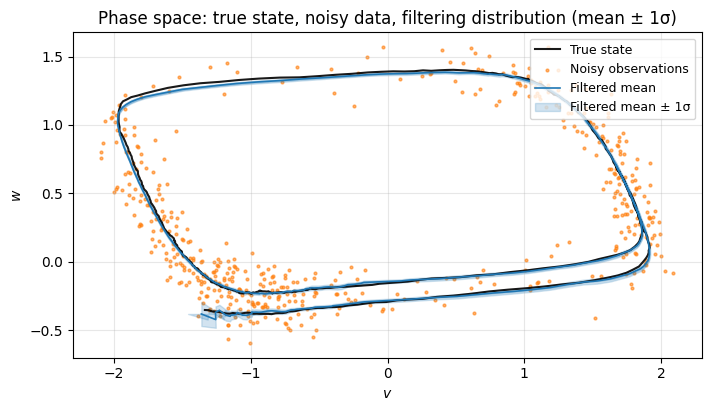

In [13]:
result = Predictive(
    data_conditioned_model,
    params={"Theta": Theta_inferred},
    num_samples=1,
    exclude_deterministic=False,
)(k_filter, obs_times=obs_times, obs_values=obs_values)

filtered_mean = jnp.squeeze(result["f_filtered_states_mean"], axis=0)  # (T+1, 2)
filtered_cov_diag = jnp.squeeze(result["f_filtered_states_cov_diag"], axis=0)  # (T+1, 2)
filtered_std = jnp.sqrt(jnp.maximum(filtered_cov_diag, 1e-10))

# Align lengths: filter may return T+1 (includes prior at t0)
n = min(len(times_1d), filtered_mean.shape[0])
t_plot = times_1d[:n]
fm = filtered_mean[:n]
fs = filtered_std[:n]
st = states[:n]
obs = obs_values[:n]

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.plot(st[:, 0], st[:, 1], "k-", label="True state", linewidth=1.5, alpha=0.9)
ax.scatter(obs[:, 0], obs[:, 1], s=4, c="C1", alpha=0.6, label="Noisy observations")
ax.plot(fm[:, 0], fm[:, 1], "C0-", label="Filtered mean", linewidth=1.2)
# Plot ±1 std as shaded bands using both dimensions of filtered_std (v and w)
ax.fill_betweenx(
    fm[:, 1], fm[:, 0] - fs[:, 0], fm[:, 0] + fs[:, 0],
    alpha=0.2, color="C0", label="Filtered mean ± 1σ"
)
ax.fill_between(
    fm[:, 0], fm[:, 1] - fs[:, 1], fm[:, 1] + fs[:, 1],
    alpha=0.2, color="C0"
)
ax.set_xlabel("$v$")
ax.set_ylabel("$w$")
ax.set_title("Phase space: true state, noisy data, filtering distribution (mean ± 1σ)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.show()